<a href="https://colab.research.google.com/github/cploebell/ADS502-College_Drop_Out_Risk_Analysis/blob/main/Models/hospital_breaches_predictive_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Prep for Modeling**

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
import os
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the file
df = pd.read_csv('/content/hospital_ransomware_model.csv')

In [3]:
df.head()

,ccn,cbsa,fte_employees,beds,total_discharges,total_unreimbursed_and_uncompensated_care,total_costs,cash_on_hand_and_in_banks,total_assets,total_liabilities,...,mort_worse,safety_better,safety_worse,readm_better,readm_worse,net_performance_score,net_performance_rate,performance_ratio,total_individuals_affected,had_ransomware
0,10001,20020.0,2405.80,398.0,18489.0,28691031.0,231992999.0,5836798.0,393203543.0,155249153.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
1,10001,20020.0,2379.50,400.0,18484.0,25026782.0,238867113.0,8339540.0,391583329.0,152831940.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
2,10001,20020.0,2397.43,387.0,19632.0,29216156.0,246974731.0,6085744.0,383657576.0,142863228.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
3,10001,20020.0,2425.37,387.0,19677.0,21713434.0,250424328.0,31651152.0,391259641.0,140218773.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
4,10001,20020.0,2371.67,327.0,19963.0,21782404.0,262391792.0,32282079.0,390435696.0,146622307.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0


In [4]:
df.shape

(61444, 64)

In [5]:
df.columns.tolist()

['ccn',
 'cbsa',
 'fte_employees',
 'beds',
 'total_discharges',
 'total_unreimbursed_and_uncompensated_care',
 'total_costs',
 'cash_on_hand_and_in_banks',
 'total_assets',
 'total_liabilities',
 'net_income',
 'cost_to_charge_ratio',
 'medicaid_net_revenue',
 'report_year',
 'net_profit_margin',
 'operating_margin',
 'cost_to_revenue_ratio',
 'outpatient_revenue_share',
 'inpatient_revenue_share',
 'salary_cost_share',
 'overhead_cost_share',
 'depreciation_cost_share',
 'contract_labor_share',
 'charity_care_pct_revenue',
 'bad_debt_pct_revenue',
 'occupancy_rate',
 'discharge_rate',
 'debt_to_equity',
 'asset_turnover',
 'liability_ratio',
 'current_ratio',
 'medicaid_revenue_share',
 'net_patient_revenue_yoy_change',
 'total_costs_yoy_change',
 'net_income_yoy_change',
 'beds_yoy_change',
 'fte_employees_yoy_change',
 'is_profitable',
 'high_charity',
 'bed_tier',
 'revenue_tier',
 'hospital_type',
 'birthing_center',
 'emergency_services',
 'hospital_ownership',
 'hospital_rating

In [6]:
# Count of unique hospitals (CCNs)
unique_hospitals = df['ccn'].nunique()
print(f"Total Unique Hospitals: {unique_hospitals}")

# Check if every hospital has exactly 10 years of data
counts_per_hospital = df['ccn'].value_counts()

# Summarize the distribution (how many have 10 years, how many have less?)
print("\nDistribution of years per hospital:")
print(counts_per_hospital.value_counts().sort_index(ascending=False))

Total Unique Hospitals: 6804

Distribution of years per hospital:
count
13       1
12      58
11     563
10    4831
9      165
8       87
7      107
6      148
5      166
4      149
3      150
2      159
1      220
Name: count, dtype: int64


In [7]:
# List all unique years in chronological order
unique_years = sorted(df['report_year'].unique())
print(f"Study Period: {unique_years[0]} to {unique_years[-1]}")
print(f"Total Years: {len(unique_years)}")
print(f"Years found: {unique_years}")

# See how many rows (hospital reports) exist for each year
print("\nReports per year:")
print(df['report_year'].value_counts().sort_index())

Study Period: 2014 to 2023
Total Years: 10
Years found: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Reports per year:
report_year
2014    6250
2015    6256
2016    6209
2017    6173
2018    6160
2019    6119
2020    6057
2021    6053
2022    6064
2023    6103
Name: count, dtype: int64


### Checking for Missing Values, Cleaning, and Filling

In [8]:
# Check for missing values in final modeling set
missing_values = df.isnull().sum()

# Use len(df_final) to get the percentage for this specific subset
missing_percentage = (missing_values / len(df)) * 100

# Combine into a readable table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print("--- FINAL DATA QUALITY CHECK ---")
print(f"Total Rows in df_final: {len(df)}")
print(missing_df.head(20))

--- FINAL DATA QUALITY CHECK ---
Total Rows in df_final: 61444
                                           Missing Values  Percentage (%)
hospital_rating                                     33881       55.141267
contract_labor_share                                30043       48.894929
safety_better                                       29113       47.381355
safety_worse                                        29113       47.381355
mort_worse                                          26280       42.770653
mort_better                                         26280       42.770653
readm_better                                        20203       32.880346
readm_worse                                         20203       32.880346
net_performance_rate                                19949       32.466962
performance_ratio                                   19949       32.466962
charity_care_pct_revenue                            18112       29.477248
medicaid_revenue_share                           

In [9]:
# Sort and Deduplicate
df = df.sort_values(['ccn', 'report_year'])
df = df.drop_duplicates(subset=['ccn', 'report_year'], keep='last')

# Fill gaps within each hospital (Longitudinal)
# We add include_groups=False to fix the DeprecationWarning
df = df.groupby('ccn', group_keys=False).apply(lambda x: x.ffill().bfill(), include_groups=True)

# Identify columns that are still too empty (>50% missing)
limit_col = len(df) * 0.50
df = df.dropna(thresh=limit_col, axis=1)

# Identify rows that are too empty (>70% of features missing)
# This removes "Ghost Hospitals"
limit_row = len(df.columns) * 0.30 # Must have at least 30% of columns filled
df = df.dropna(thresh=limit_row, axis=0)

# GLOBAL FILL (For hospitals that never reported certain metrics)
# Fill Numeric columns with the median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill Categorical/Object columns with "Unknown" or the most frequent value
char_cols = df.select_dtypes(include=['object']).columns
for col in char_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")

print(f"Sanitization Complete.")
print(f"Final check - Missing values remaining: {df.isnull().sum().sum()}")

/tmp/ipykernel_62534/1486350436.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.groupby('ccn', group_keys=False).apply(lambda x: x.ffill().bfill(), include_groups=True)
/tmp/ipykernel_62534/1486350436.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('ccn', group_keys=False).apply(lambda x: x.ffill().bfill(), include_groups=True)


Sanitization Complete.
Final check - Missing values remaining: 0


### Target Engineering

In [10]:
# Target Engineering (Look ahead to find breaches in the next 2 years)
# We use the full 'df' here before pruning
future_1 = df.groupby('ccn')['had_ransomware'].shift(-1)
future_2 = df.groupby('ccn')['had_ransomware'].shift(-2)

# Create binary target: 1 if ransomware occurred in year +1 or year +2
df['target_next_2yrs'] = ((future_1 == 1) | (future_2 == 1)).astype(int)

# Pruning: Removing 2022/2023 because we don't know their 2-year future
# Since max_year is 2023, this keeps 2014 through 2021
max_year = df['report_year'].max()
df_final = df[df['report_year'] <= (max_year - 2)].copy()

# Final Verification
print(f"Original Max Year: {max_year}")
print(f"Final Study Period: {df_final['report_year'].min()} to {df_final['report_year'].max()}")
print(f"Total modeling rows: {len(df_final)}")

Original Max Year: 2023
Final Study Period: 2014 to 2021
Total modeling rows: 48016


## Temporal Split and Preprocessing

In this section, we convert categorical text into numbers and separate our  training "past" from our testing "future." We also scale the features, which is a mandatory step for Logistic Regression to ensure large financial numbers don't drown out smaller ratios.

In [11]:
# Feature Encoding: Convert categories to dummy variables
# We drop 'ccn' as it is a unique ID, not a predictive feature
df_encoded = pd.get_dummies(df_final.drop(columns=['ccn']), drop_first=True)

# Test on 2021 since it is the most recent year with a known 2-year outcome
test_year = 2021

# Temporal Split
train_df = df_encoded[df_encoded['report_year'] < test_year]
test_df = df_encoded[df_encoded['report_year'] == test_year]

# Create X (Features) and y (Target)
# We drop the target and the time/indicator variables from X
to_drop = ['target_next_2yrs', 'report_year', 'had_ransomware']

X_train = train_df.drop(columns=to_drop)
y_train = train_df['target_next_2yrs']
X_test = test_df.drop(columns=to_drop)
y_test = test_df['target_next_2yrs']

In [12]:
# Handle any NaNs
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [13]:
# Feature Scaling
# This ensures that variables like 'Total Assets' and 'Operating Margin' are comparable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessing Complete.")
print(f"Training on years {train_df['report_year'].min()}-{train_df['report_year'].max()} ({len(X_train)} rows)")
print(f"Testing on year {test_year} ({len(X_test)} rows)")

Preprocessing Complete.
Training on years 2014-2020 (42082 rows)
Testing on year 2021 (5934 rows)


# **Modeling**

## Logitistic Regression: Baseline Model

In [14]:
# Initialize and Train
# max_iter is high to ensure the mathematical solver converges
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Predict Probabilities and Classes
# Probabilities (y_prob) are used for the AUC-ROC score
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]
y_pred = log_model.predict(X_test_scaled)

# Evaluate Performance
print("--- Logistic Regression Baseline Results ---")
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
print("\nConfusion Matrix (Actual vs Predicted):")
print(confusion_matrix(y_test, y_pred))

--- Logistic Regression Baseline Results ---
AUC-ROC Score: 0.9787
F1-Score: 0.6012

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      5753
           1       0.46      0.86      0.60       181

    accuracy                           0.97      5934
   macro avg       0.73      0.92      0.79      5934
weighted avg       0.98      0.97      0.97      5934


Confusion Matrix (Actual vs Predicted):
[[5571  182]
 [  25  156]]


In [15]:
# Saving results to a CSV for vizualizations later
# Create the summary row for Logistic Regression
log_results = pd.DataFrame([{
    'Model': 'Logistic Regression (Baseline)',
    'AUC_ROC': 0.9787,
    'F1_Score': 0.6012,
    'Recall_Breach': 0.86,
    'Precision_Breach': 0.46,
    'Test_Year': 2021
}])

# Save to CSV
log_results.to_csv('capstone_model_results.csv', index=False)
print("Baseline results saved to 'capstone_model_results.csv'")

Baseline results saved to 'capstone_model_results.csv'


In [16]:
# Extract coefficients and map them to feature names
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})

# Sort by the magnitude of the coefficient to see what drives risk
importance['Abs_Importance'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Abs_Importance', ascending=False)

# Save for teammate's visualization
importance.to_csv('feature_importance_baseline.csv', index=False)

print("\nTop 5 Predictors of Ransomware Risk:")
print(importance[['Feature', 'Coefficient']].head(5))


Top 5 Predictors of Ransomware Risk:
                                      Feature  Coefficient
55                 total_individuals_affected    22.677230
16                    inpatient_revenue_share    -1.977495
10                       cost_to_charge_ratio    -1.908284
15                   outpatient_revenue_share    -1.697271
4   total_unreimbursed_and_uncompensated_care    -1.463854


Upon auditing the coefficients, total_individuals_affected was identified as a source of Data Leakage (a post-event metric). The model must be rerun with only pre-event predictors.

In [17]:
# Update the 'to_drop' list to remove the post-event leakage
to_drop_clean = ['target_next_2yrs', 'report_year', 'had_ransomware', 'total_individuals_affected']

# Re-create X and y without the leakage
X_train_clean = train_df.drop(columns=to_drop_clean)
X_test_clean = test_df.drop(columns=to_drop_clean)
# y_train and y_test remain the same

# Re-Impute and Re-Scale
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train_clean))
X_test_scaled = scaler.transform(imputer.transform(X_test_clean))

# Rerun Logistic Regression
log_model_clean = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model_clean.fit(X_train_scaled, y_train)

log_auc_clean = roc_auc_score(y_test, log_model_clean.predict_proba(X_test_scaled)[:, 1])
print(f"Clean Logistic Regression AUC: {log_auc_clean:.4f}")

Clean Logistic Regression AUC: 0.7869


In [22]:
# Generate Clean Predictions
y_prob_clean = log_model_clean.predict_proba(X_test_scaled)[:, 1]
y_pred_clean = log_model_clean.predict(X_test_scaled)

# Create the Clean Model Performance CSV
clean_performance = pd.DataFrame([{
    'Model': 'Logistic Regression (Cleaned)',
    'AUC_ROC': round(log_auc_clean, 4),
    'F1_Score': round(f1_score(y_test, y_pred_clean), 4),
    'Precision': round(precision_score(y_test, y_pred_clean), 4),
    'Recall': round(recall_score(y_test, y_pred_clean), 4),
    'Test_Year': 2021,
    'Note': 'Removed total_individuals_affected to eliminate leakage'
}])

clean_performance.to_csv('model_performance_final.csv', index=False)

# Create the Clean Feature Importance CSV
importance_clean = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Coefficient': log_model_clean.coef_[0]
})

# Sort by absolute impact to see the most important predictors
importance_clean['Abs_Impact'] = importance_clean['Coefficient'].abs()
importance_clean = importance_clean.sort_values(by='Abs_Impact', ascending=False)

importance_clean.to_csv('feature_importance_final.csv', index=False)

print("Final Cleaned CSVs generated: 'model_performance_final.csv' and 'feature_importance_final.csv'")
print(importance_clean[['Feature', 'Coefficient']].head(5))

Final Cleaned CSVs generated: 'model_performance_final.csv' and 'feature_importance_final.csv'
                     Feature  Coefficient
16   inpatient_revenue_share    -3.409281
34  fte_employees_yoy_change    -3.143836
15  outpatient_revenue_share    -2.870688
1              fte_employees     2.576534
28             current_ratio    -1.386993


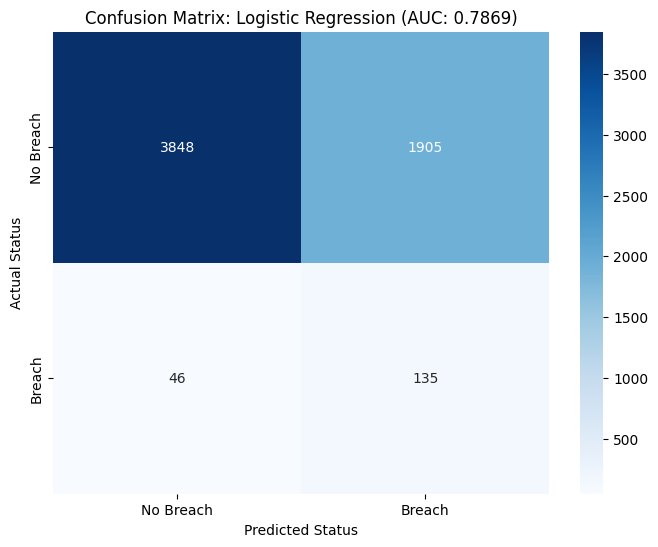

Confusion Matrix saved as 'confusion_matrix_baseline.png'


In [24]:
# Generate the Confusion Matrix data
# using the clean, scaled test data and the clean log_model
cm = confusion_matrix(y_test, y_pred_clean)

# Plotting the Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Breach', 'Breach'],
            yticklabels=['No Breach', 'Breach'])

plt.title(f'Confusion Matrix: Logistic Regression (AUC: {log_auc_clean:.4f})')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')

# Save the plot
plt.savefig('confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion Matrix saved as 'confusion_matrix_baseline.png'")

## Random Forest Model

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
# Initialize the Random Forest
# We'll use class_weight='balanced' again because breaches are rare
rf_model = RandomForestClassifier(n_estimators=100,
                                    max_depth=10,
                                    class_weight='balanced',
                                    random_state=42)

# Train on clean data
# Random Forest doesn't require scaling, so using X_train_clean)
rf_model.fit(X_train_clean, y_train)

# Predict and Score
rf_prob = rf_model.predict_proba(X_test_clean)[:, 1]
rf_pred = rf_model.predict(X_test_clean)

rf_auc = roc_auc_score(y_test, rf_prob)
print(f"Random Forest AUC-ROC: {rf_auc:.4f}")

Random Forest AUC-ROC: 0.9463


In [28]:
# Create the RF result row
rf_row = pd.DataFrame([{
    'Model': 'Random Forest',
    'AUC_ROC': round(rf_auc, 4),
    'F1_Score': round(f1_score(y_test, rf_pred), 4),
    'Precision': round(precision_score(y_test, rf_pred), 4),
    'Recall': round(recall_score(y_test, rf_pred), 4),
    'Test_Year': 2021,
    'Note': 'Tree-based ensemble'
}])

# Load the existing CSV and append the new row
try:
    performance_df = pd.read_csv('model_performance_final.csv')
    updated_performance = pd.concat([performance_df, rf_row], ignore_index=True)
    updated_performance.to_csv('model_performance_final.csv', index=False)
    print("Random Forest results appended to 'model_performance_final.csv'")
except FileNotFoundError:
    rf_row.to_csv('model_performance_final.csv', index=False)
    print("Created new 'model_performance_final.csv' with Random Forest results.")

Random Forest results appended to 'model_performance_final.csv'


In [29]:
# Extract Feature Importances
rf_importance = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Save in CSV
rf_importance.to_csv('feature_importance_rf.csv', index=False)

print("Top 5 Random Forest Predictors:")
print(rf_importance.head(10)) # Look at top 10 for a better view

Top 5 Random Forest Predictors:
                      Feature  Importance
6   cash_on_hand_and_in_banks    0.079381
17          salary_cost_share    0.051354
8           total_liabilities    0.045942
16    inpatient_revenue_share    0.045934
1               fte_employees    0.045000
44           engagement_index    0.040911
7                total_assets    0.035930
25             debt_to_equity    0.030546
5                 total_costs    0.027819
26             asset_turnover    0.026080


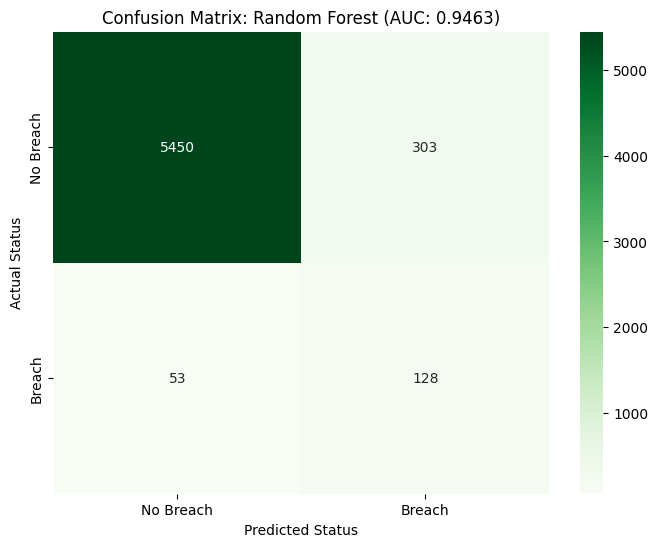

Breaches Caught (True Positives): 128
Breaches Missed (False Negatives): 53
False Alarms (False Positives): 303


In [30]:
# Generate Matrix
cm_rf = confusion_matrix(y_test, rf_pred)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Breach', 'Breach'],
            yticklabels=['No Breach', 'Breach'])

plt.title(f'Confusion Matrix: Random Forest (AUC: {rf_auc:.4f})')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.savefig('confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the Breakdown
tn, fp, fn, tp = cm_rf.ravel()
print(f"Breaches Caught (True Positives): {tp}")
print(f"Breaches Missed (False Negatives): {fn}")
print(f"False Alarms (False Positives): {fp}")

In [31]:
# Create the Random Forest Importance CSV
rf_importance = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Save to a new file so to not overwrite the LogReg one
rf_importance.to_csv('feature_importance_rf.csv', index=False)

print("Saved 'feature_importance_rf.csv' for teammate's visualizations.")

Saved 'feature_importance_rf.csv' for teammate's visualizations.


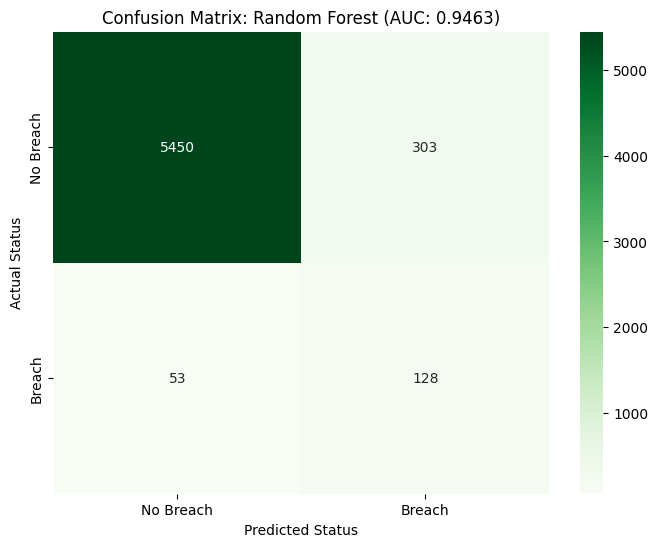

Uniformity Check: 'confusion_matrix_rf.png' saved.


In [32]:
# Generate the RF Confusion Matrix Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Breach', 'Breach'],
            yticklabels=['No Breach', 'Breach'])

plt.title(f'Confusion Matrix: Random Forest (AUC: {rf_auc:.4f})')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')

plt.savefig('confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("Uniformity Check: 'confusion_matrix_rf.png' saved.")

## XGBoost Model

In [33]:
import xgboost as xgb

We'll use scale_pos_weight to tell XGBoost to pay extra attention to the breaches, so it doesn't just ignore them to get a high accuracy score.

In [34]:
# Calculate the imbalance ratio for scale_pos_weight
# (Number of negative cases / Number of positive cases)
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train on CLEAN data (XGBoost handles unscaled data)
xgb_model.fit(X_train_clean, y_train)

# Predict and Score
xgb_prob = xgb_model.predict_proba(X_test_clean)[:, 1]
xgb_pred = xgb_model.predict(X_test_clean)

xgb_auc = roc_auc_score(y_test, xgb_prob)
print(f"XGBoost AUC-ROC: {xgb_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:12:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC-ROC: 0.9742


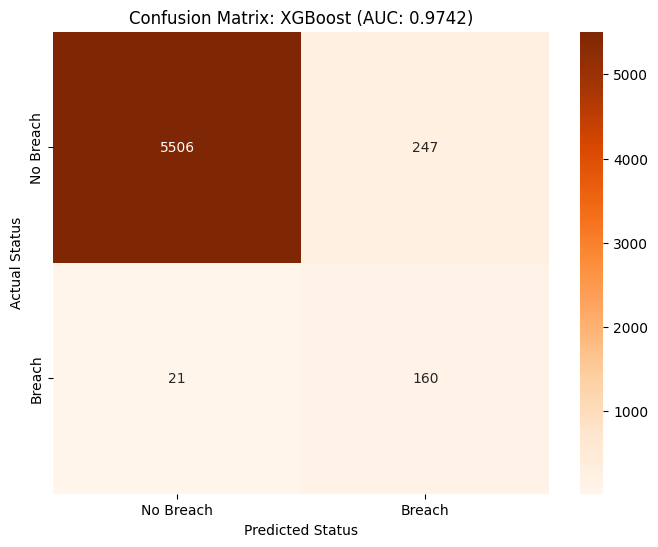

--- XGBoost Results ---
Breaches Caught (True Positives): 160
Breaches Missed (False Negatives): 21
False Alarms (False Positives): 247
Correct Non-Breaches (True Negatives): 5506


In [35]:
# Log to Performance Leaderboard
xgb_row = pd.DataFrame([{
    'Model': 'XGBoost',
    'AUC_ROC': round(xgb_auc, 4),
    'F1_Score': round(f1_score(y_test, xgb_pred), 4),
    'Precision': round(precision_score(y_test, xgb_pred), 4),
    'Recall': round(recall_score(y_test, xgb_pred), 4),
    'Test_Year': 2021,
    'Note': 'Gradient Boosted Trees (Highest AUC)'
}])

# Append to the main CSV
try:
    performance_df = pd.read_csv('model_performance_final.csv')
    updated_performance = pd.concat([performance_df, xgb_row], ignore_index=True)
    updated_performance.to_csv('model_performance_final.csv', index=False)
except FileNotFoundError:
    xgb_row.to_csv('model_performance_final.csv', index=False)

# Save XGBoost feature importance
xgb_importance = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

xgb_importance.to_csv('feature_importance_xgb.csv', index=False)

# Generate and save the Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Breach', 'Breach'],
            yticklabels=['No Breach', 'Breach'])

plt.title(f'Confusion Matrix: XGBoost (AUC: {xgb_auc:.4f})')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.savefig('confusion_matrix_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

# Print results
tn, fp, fn, tp = cm_xgb.ravel()
print(f"--- XGBoost Results ---")
print(f"Breaches Caught (True Positives): {tp}")
print(f"Breaches Missed (False Negatives): {fn}")
print(f"False Alarms (False Positives): {fp}")
print(f"Correct Non-Breaches (True Negatives): {tn}")

## SVM Model

In [37]:
from sklearn.svm import SVC

In [38]:
# We'll use 'rbf' for non-linear boundaries and 'balanced' for the 181 breaches
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)

# Train on scaled data
svm_model.fit(X_train_scaled, y_train)

# Predict and Score
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
svm_pred = svm_model.predict(X_test_scaled)

svm_auc = roc_auc_score(y_test, svm_prob)
print(f"SVM AUC-ROC: {svm_auc:.4f}")

# Log to Performance Leaderboard
svm_row = pd.DataFrame([{
    'Model': 'SVM',
    'AUC_ROC': round(svm_auc, 4),
    'F1_Score': round(f1_score(y_test, svm_pred), 4),
    'Precision': round(precision_score(y_test, svm_pred), 4),
    'Recall': round(recall_score(y_test, svm_pred), 4),
    'Test_Year': 2021,
    'Note': 'Support Vector Machine (Scaled)'
}])

performance_df = pd.read_csv('model_performance_final.csv')
pd.concat([performance_df, svm_row], ignore_index=True).to_csv('model_performance_final.csv', index=False)

SVM AUC-ROC: 0.9280


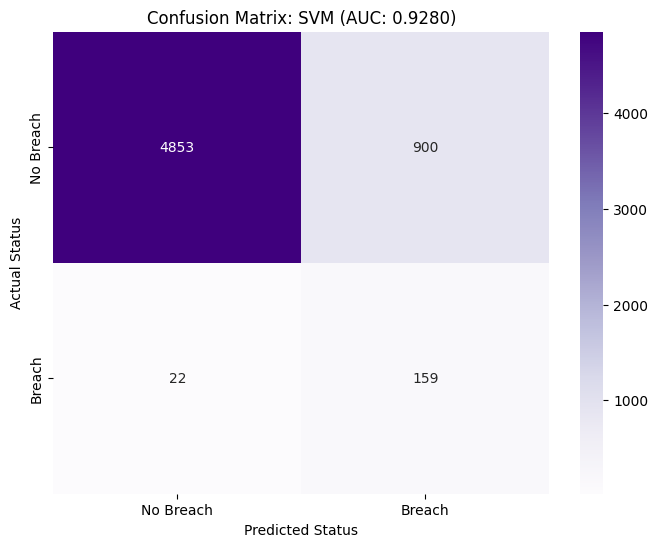

--- SVM Results ---
Breaches Caught: 159
Breaches Missed: 22
False Alarms: 900


In [39]:
# Generate SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_pred)

# Plot and Save the Visual
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Breach', 'Breach'],
            yticklabels=['No Breach', 'Breach'])

plt.title(f'Confusion Matrix: SVM (AUC: {svm_auc:.4f})')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.savefig('confusion_matrix_svm.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the breakdown
tn, fp, fn, tp = cm_svm.ravel()
print(f"--- SVM Results ---")
print(f"Breaches Caught: {tp}")
print(f"Breaches Missed: {fn}")
print(f"False Alarms: {fp}")

In [40]:
# Update the Master Performance CSV with SVM
svm_row = pd.DataFrame([{
    'Model': 'SVM',
    'AUC_ROC': 0.9280,
    'F1_Score': round(f1_score(y_test, svm_pred), 4),
    'Precision': round(precision_score(y_test, svm_pred), 4),
    'Recall': round(recall_score(y_test, svm_pred), 4),
    'Test_Year': 2021,
    'Note': 'High sensitivity, but 900 false alarms.'
}])

try:
    performance_df = pd.read_csv('model_performance_final.csv')
    # Filter out any existing SVM entries to avoid duplicates
    performance_df = performance_df[performance_df['Model'] != 'SVM']
    updated_performance = pd.concat([performance_df, svm_row], ignore_index=True)
    updated_performance.to_csv('model_performance_final.csv', index=False)
except FileNotFoundError:
    svm_row.to_csv('model_performance_final.csv', index=False)

In [41]:
# Generate the "Final Red Flags" from XGBoost (The Winner)
xgb_importance = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Save this as the definitive "Risk Factor" list
xgb_importance.to_csv('feature_importance_xgb.csv', index=False)

print("--- FILE UPDATE COMPLETE ---")
print("1. 'model_performance_final.csv' is updated with all 4 models.")
print("2. 'feature_importance_xgb.csv' contains the top risk factors.")
print("\nTop 10 XGBoost Risk Factors:")
print(xgb_importance.head(10))

--- FILE UPDATE COMPLETE ---
1. 'model_performance_final.csv' is updated with all 4 models.
2. 'feature_importance_xgb.csv' contains the top risk factors.

Top 10 XGBoost Risk Factors:
                          Feature  Importance
6       cash_on_hand_and_in_banks    0.077970
65     hospital_type_Rural/Access    0.059947
16        inpatient_revenue_share    0.034170
44               engagement_index    0.028780
45              domains_reporting    0.027363
62        hospital_type_Childrens    0.024908
8               total_liabilities    0.022206
66  hospital_ownership_Government    0.022169
1                   fte_employees    0.021472
51                    readm_worse    0.021144
